# Sequential Bayesian Updating

In many applications, data arrives in **batches** rather than all at once. A sensor network reports readings every hour. A clinical trial enrolls patients in stages. An online retailer observes purchases day by day. In each case, we want to **update our beliefs incrementally** as new evidence arrives, carrying the posterior from one batch forward as the prior for the next.

ProbPipe's transition framework builds on the same primitives you already know — `condition_on`, `from_distribution`, the converter registry, and the inference method registry — and adds a thin iteration layer on top.

**Outline:**

1. [Problem setup](#1.-Problem-Setup) — Gaussian mean estimation with streaming data
2. [Single-batch updating: IncrementalConditioner](#2.-Single-Batch-Updating:-IncrementalConditioner) — the stateful convenience API
3. [Multi-batch updating: update_all and iterate](#3.-Multi-Batch-Updating:-update_all-and-iterate) — folding over data batches
4. [Keeping posteriors parametric: with_conversion](#4.-Keeping-Posteriors-Parametric:-with_conversion) — `from_distribution` after each step
5. [Resampling degenerate particles: with_resampling](#5.-Resampling-Degenerate-Particles:-with_resampling) — tempering and SMC
6. [Tracking per-step diagnostics: StepResult](#6.-Tracking-Per-Step-Diagnostics:-StepResult) — attaching auxiliary info
7. [Callbacks and early stopping](#7.-Callbacks-and-Early-Stopping) — monitoring the iteration
8. [Provenance tracking](#8.-Provenance-Tracking) — automatic lineage through the trajectory
9. [Composing and nesting](#9.-Composing-and-Nesting) — combining combinators, inner loops
10. [Summary](#10.-Summary)

## 1. Problem Setup

We'll use a simple running example throughout: estimating a 2-D mean vector $\boldsymbol{\mu}$ from noisy observations.

$$y_i \sim \mathcal{N}(\boldsymbol{\mu},\, I), \qquad \boldsymbol{\mu} \sim \mathcal{N}(\mathbf{0},\, 10\,I)$$

We generate 200 observations and split them into 4 batches of 50 — simulating data that arrives over time.

In [1]:
import warnings
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype.*float64.*")

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (
    MultivariateNormal, EmpiricalDistribution,
    condition_on, from_distribution, mean, provenance_ancestors,
    sample as pp_sample,
    StepResult, TransitionTrace, iterate,
    with_conversion, with_resampling,
    IncrementalConditioner,
)
from probpipe.modeling import Likelihood

rng = np.random.default_rng(42)

In [2]:
# Ground truth
true_mu = jnp.array([2.0, -1.0])

# Generate observations and split into batches
y_all = jnp.array(rng.multivariate_normal(np.array(true_mu), np.eye(2), size=200))
batches = [y_all[i:i+50] for i in range(0, 200, 50)]

# Prior
prior = MultivariateNormal(loc=jnp.zeros(2), cov=10.0 * jnp.eye(2), name="prior")

# Likelihood: isotropic Gaussian
class GaussianLikelihood:
    def log_likelihood(self, params, data):
        residuals = jnp.asarray(data) - params[None, :]
        return -0.5 * jnp.sum(residuals ** 2)

likelihood = GaussianLikelihood()

print(f"True mu:    {true_mu}")
print(f"Batches:    {len(batches)} x {batches[0].shape[0]} observations")
print(f"Prior mean: {mean(prior)}")

True mu:    [ 2. -1.]
Batches:    4 x 50 observations
Prior mean: [0. 0.]


### Conditioning function

By default, ProbPipe's `condition_on` dispatches through the **inference method registry**, selecting an appropriate backend based on what the model supports. You can also force a specific method with `method="tfp_nuts"`, or provide your own conditioning function entirely — ProbPipe's dispatch system is designed for this kind of customization.

For this tutorial, we use a **fast analytic conditioning function** that computes the conjugate Gaussian posterior exactly. In practice you'd just use the defaults — `IncrementalConditioner(prior, likelihood)` dispatches to `condition_on` automatically.

In [3]:
def gaussian_conjugate_condition(model, data, **kwargs):
    """Conjugate Gaussian posterior (known unit variance).

    Implements the same interface as condition_on: takes a model and
    data, returns a posterior distribution.
    """
    prior_dist = model["parameters"]
    prior_mean = mean(prior_dist)
    data = jnp.asarray(data)
    n = data.shape[0]
    prior_prec = jnp.linalg.inv(jnp.array([[10., 0.], [0., 10.]]))
    data_prec = n * jnp.eye(2)
    post_prec = prior_prec + data_prec
    post_cov = jnp.linalg.inv(post_prec)
    post_mean = post_cov @ (prior_prec @ prior_mean + data_prec @ jnp.mean(data, axis=0))
    key = jax.random.PRNGKey(hash(str(data[:3])) % (2**31))
    samples = jax.random.multivariate_normal(key, post_mean, post_cov, shape=(500,))
    return EmpiricalDistribution(samples, name="posterior")

---

## 2. Single-Batch Updating: IncrementalConditioner

`IncrementalConditioner` is the simplest way to do sequential Bayesian updating. It maintains a **current posterior** (initially the prior) and provides `update()` to condition on one new batch at a time — each call advances the state.

In [4]:
conditioner = IncrementalConditioner(
    prior=prior,
    likelihood=likelihood,
    condition_fn=gaussian_conjugate_condition,
)

print(f"Initial: {mean(conditioner.curr_posterior)}")

for i, batch in enumerate(batches):
    posterior = conditioner.update(data=batch)
    print(f"After batch {i+1}: {mean(conditioner.curr_posterior)}")

print(f"\nTrue mu: {true_mu}")

Initial: [0. 0.]


W0406 17:55:28.532596 3326517 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


After batch 1: [ 1.9744722 -1.0574352]


After batch 2: [ 1.9929284 -1.0288035]
After batch 3: [ 1.9854827 -1.101003 ]
After batch 4: [ 2.1388407 -0.9321192]

True mu: [ 2. -1.]


Each `update()` call returns the posterior `Distribution` and advances the internal state. The posterior sharpens toward the true value as more data arrives.

Note that the posterior from each step is an `EmpiricalDistribution` (MCMC samples). When this is fed back as the next prior, the conditioning step automatically converts it to a form that supports `log_prob` (via ProbPipe's converter registry) before building the model.

---

## 3. Multi-Batch Updating: `update_all` and `iterate`

When you have all batches upfront, `update_all` processes them in one call and returns a `TransitionTrace` — a trajectory containing every intermediate posterior. It also updates the conditioner's state to the final posterior.

In [5]:
conditioner = IncrementalConditioner(
    prior=prior,
    likelihood=likelihood,
    condition_fn=gaussian_conjugate_condition,
)

trace = conditioner.update_all(data_batches=batches)

print(f"Batches processed: {len(trace)}")
print(f"Final mean:        {mean(trace.final)}")
print(f"State updated:     {conditioner.curr_posterior is trace.final}")

Batches processed: 4
Final mean:        [ 2.1388407 -0.9321192]
State updated:     True


Under the hood, `update_all` calls `iterate(self.step, self.curr_posterior, data_batches)`. The `.step` property exposes the underlying step function, which you can use directly with `iterate` for full control — this is the **functional escape hatch** for composing with combinators (see [Section 4](#4.-Keeping-Posteriors-Parametric:-with_conversion)).

To visualize convergence, we use `with_conversion` to keep posteriors parametric so we can sample from them cleanly:

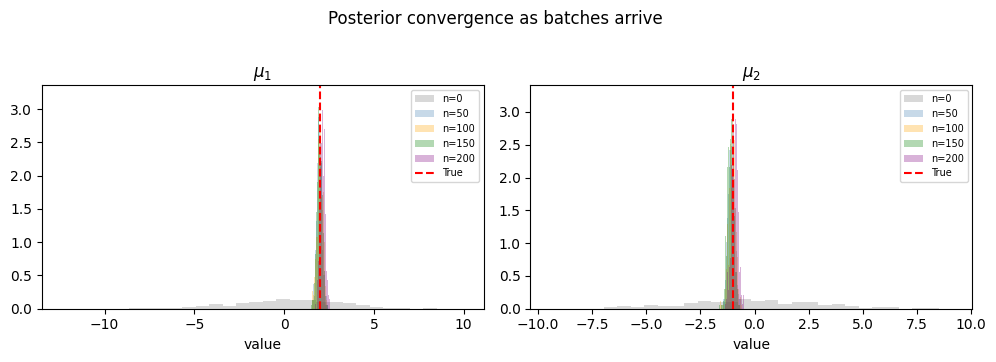

In [6]:
# Use the functional API with with_conversion for parametric posteriors
approx_step = with_conversion(conditioner.step, MultivariateNormal, name="posterior")
trace = iterate(approx_step, prior, batches)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

colors = ['gray', 'steelblue', 'orange', 'green', 'purple']
for i, dist in enumerate(trace.distributions):
    n_seen = i * 50
    samples = np.array(pp_sample(dist, key=jax.random.PRNGKey(i), sample_shape=(500,)))
    ax1.hist(samples[:, 0], bins=30, density=True,
             alpha=0.3, color=colors[i], label=f'n={n_seen}')
    ax2.hist(samples[:, 1], bins=30, density=True,
             alpha=0.3, color=colors[i], label=f'n={n_seen}')

for ax, true_val in [(ax1, true_mu[0]), (ax2, true_mu[1])]:
    ax.axvline(float(true_val), color='red', linestyle='--', label=f'True')
    ax.set_xlabel('value')
    ax.legend(fontsize=7)

ax1.set_title(r'$\mu_1$')
ax2.set_title(r'$\mu_2$')
fig.suptitle('Posterior convergence as batches arrive', y=1.02)
plt.tight_layout()
plt.show()

---

## 4. Keeping Posteriors Parametric: `with_conversion`

Each conditioning step typically returns MCMC samples (an `EmpiricalDistribution`). But we often want the *next* prior to be parametric — a `MultivariateNormal` fit to those samples — so the model stays well-defined.

`with_conversion` wraps a step function to call ProbPipe's `from_distribution` after each step — the same conversion operation used everywhere in ProbPipe, dispatching through the converter registry. It also stores the pre-conversion distribution in `info["pre_conversion"]`.

In [7]:
approx_step = with_conversion(conditioner.step, MultivariateNormal, name="posterior")
trace = iterate(approx_step, prior, batches)

for i, result in enumerate(trace):
    dist = result.distribution
    pre = result.info["pre_conversion"]
    print(f"  Step {i}: {type(pre).__name__:30s} -> {type(dist).__name__}")

print(f"\nAll posteriors are parametric: {all(isinstance(r.distribution, MultivariateNormal) for r in trace)}")

  Step 0: ArrayEmpiricalDistribution     -> MultivariateNormal
  Step 1: ArrayEmpiricalDistribution     -> MultivariateNormal
  Step 2: ArrayEmpiricalDistribution     -> MultivariateNormal
  Step 3: ArrayEmpiricalDistribution     -> MultivariateNormal

All posteriors are parametric: True


You can also target a protocol instead of a concrete type — e.g., `with_conversion(step, SupportsLogProb)` would convert via the protocol converter (which defaults to KDE).

---

## 5. Resampling Degenerate Particles: `with_resampling`

In **tempering** and **SMC** algorithms, particles carry importance weights that get updated at each step. As the target distribution sharpens, a few particles tend to dominate — the *effective sample size* (ESS) collapses and the approximation degrades.

`with_resampling` monitors ESS after each step and, when `ESS/N` drops below a threshold, resamples to produce equally-weighted particles.

In [8]:
def tempering_step(dist, beta_increment):
    """Reweight particles by a tempered quadratic likelihood."""
    samples = dist.samples
    target = jnp.array([2.0, 2.0])
    log_lik = -0.5 * jnp.sum((samples - target) ** 2, axis=1)
    old_log_w = dist._w.log_normalized
    new_log_w = old_log_w + beta_increment * log_lik
    return EmpiricalDistribution(samples, log_weights=new_log_w)

# Wide prior particles
key = jax.random.PRNGKey(0)
prior_samples = jax.random.normal(key, shape=(500, 2)) * 3.0
particles = EmpiricalDistribution(prior_samples, name="prior_particles")

# Temper in 5 equal increments: beta goes 0 -> 1
betas = [0.2] * 5

# Without resampling
trace_no = iterate(tempering_step, particles, betas)

# With resampling (ESS/N < 50% triggers resampling)
trace_yes = iterate(
    with_resampling(tempering_step, ess_threshold=0.5),
    particles, betas,
)

In [9]:
ess_no = [float(d.effective_sample_size) for d in trace_no.distributions[1:]]
ess_yes = trace_yes.info_values('ess')
resampled = trace_yes.info_values('resampled')

print("Without resampling:")
for i, e in enumerate(ess_no):
    print(f"  Step {i}: ESS = {e:5.1f} ({e/500*100:2.0f}%)")

print("\nWith resampling (threshold = 50%):")
for i, (e, r) in enumerate(zip(ess_yes, resampled)):
    tag = ' [resampled]' if r else ''
    print(f"  Step {i}: ESS = {e:5.1f} ({e/500*100:2.0f}%){tag}")

Without resampling:
  Step 0: ESS = 245.5 (49%)
  Step 1: ESS = 160.4 (32%)
  Step 2: ESS = 118.8 (24%)
  Step 3: ESS =  93.6 (19%)
  Step 4: ESS =  76.5 (15%)

With resampling (threshold = 50%):
  Step 0: ESS = 245.5 (49%) [resampled]
  Step 1: ESS = 420.3 (84%)
  Step 2: ESS = 334.4 (67%)
  Step 3: ESS = 271.8 (54%)
  Step 4: ESS = 226.4 (45%) [resampled]


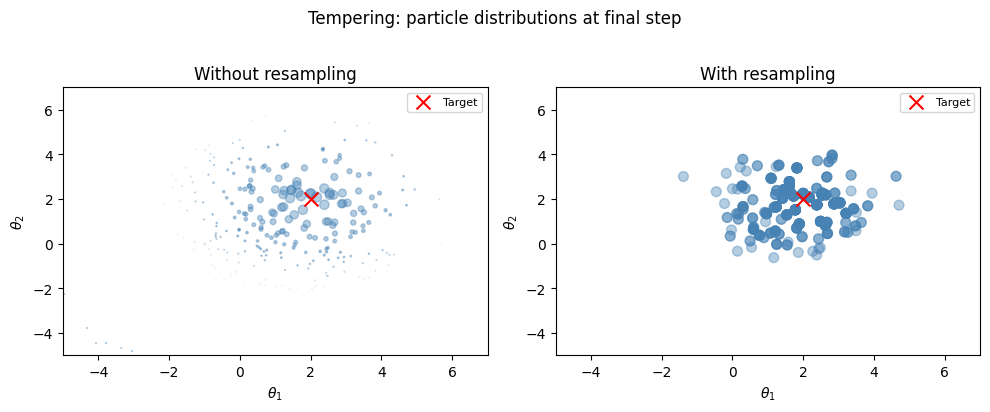

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, tr, title in [(axes[0], trace_no, 'Without resampling'),
                       (axes[1], trace_yes, 'With resampling')]:
    final = tr.final
    s = np.array(final.samples)
    w = np.array(final.weights)
    sizes = w / w.max() * 50
    ax.scatter(s[:, 0], s[:, 1], s=sizes, alpha=0.4, c='steelblue')
    ax.scatter([2.0], [2.0], c='red', marker='x', s=100, zorder=5, label='Target')
    ax.set_xlim(-5, 7)
    ax.set_ylim(-5, 7)
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('Tempering: particle distributions at final step', y=1.02)
plt.tight_layout()
plt.show()

Without resampling, most particles (sized by weight) are negligible — a few dominate. With resampling, particles are redistributed to equally-weighted copies of the high-probability particles.

---

## 6. Tracking Per-Step Diagnostics: StepResult

When a step function returns a `StepResult` instead of a bare `Distribution`, it can attach an `info` dict with arbitrary diagnostics. The `TransitionTrace` collects these and provides accessors.

In [11]:
def shift_step(dist, offset):
    return EmpiricalDistribution(dist.samples + offset)

def shift_with_diagnostics(dist, offset):
    new_samples = dist.samples + offset
    new_dist = EmpiricalDistribution(new_samples)
    return StepResult(
        distribution=new_dist,
        info={"offset": float(offset), "sample_mean": float(jnp.mean(new_samples))},
    )

start = EmpiricalDistribution(jnp.zeros((200, 2)))
trace = iterate(shift_with_diagnostics, start, [1.0, 2.0, 3.0])

for i, info in enumerate(trace.infos):
    print(f"  Step {i}: offset={info['offset']:.1f}, sample_mean={info['sample_mean']:.1f}")

print(f"\nAll offsets: {trace.info_values('offset')}")

  Step 0: offset=1.0, sample_mean=1.0
  Step 1: offset=2.0, sample_mean=3.0
  Step 2: offset=3.0, sample_mean=6.0

All offsets: [1.0, 2.0, 3.0]


`TransitionTrace` supports iteration and indexing:

In [12]:
print(f"trace[0].info:  {trace[0].info}")
print(f"trace[-1].info: {trace[-1].info}")

print(f"\nIterating:")
for result in trace:
    print(f"  offset={result.info['offset']}, mean={result.info['sample_mean']:.1f}")

print(f"\nlen(trace):              {len(trace)}")
print(f"len(trace.distributions): {len(trace.distributions)}  (includes initial)")

trace[0].info:  {'offset': 1.0, 'sample_mean': 1.0}
trace[-1].info: {'offset': 3.0, 'sample_mean': 6.0}

Iterating:
  offset=1.0, mean=1.0
  offset=2.0, mean=3.0
  offset=3.0, mean=6.0

len(trace):              3
len(trace.distributions): 4  (includes initial)


---

## 7. Callbacks and Early Stopping

Pass a `callback` to `iterate` for logging or early termination. Return `False` to stop early.

In [13]:
def stop_when_converged(i, result):
    m = float(jnp.mean(result.distribution.samples))
    print(f"  Step {i}: mean = {m:.2f}")
    if m > 3.0:
        print(f"  -> Stopping (mean exceeded 3.0)")
        return False

start = EmpiricalDistribution(jnp.zeros((200, 2)))
trace = iterate(shift_step, start, [1.0, 1.5, 2.0, 2.5], callback=stop_when_converged)
print(f"Steps completed: {len(trace)} of 4")

  Step 0: mean = 1.00
  Step 1: mean = 2.50
  Step 2: mean = 4.50
  -> Stopping (mean exceeded 3.0)
Steps completed: 3 of 4


---

## 8. Provenance Tracking

`iterate` automatically attaches provenance to each step's output, linking it to the previous distribution. If a step function sets its own provenance, `iterate` respects it.

In [14]:
start = EmpiricalDistribution(jnp.zeros((100, 2)), name="start")
trace = iterate(shift_step, start, [1.0, 2.0, 3.0])

for i, result in enumerate(trace):
    src = result.distribution.source
    parent_name = src.parents[0].name or type(src.parents[0]).__name__
    print(f"  Step {i}: operation='{src.operation}', parent='{parent_name}'")

ancestors = provenance_ancestors(trace.final)
print(f"\nAncestor chain: {[a.name or type(a).__name__ for a in ancestors]}")

  Step 0: operation='iterate', parent='start'
  Step 1: operation='iterate', parent='ArrayEmpiricalDistribution'
  Step 2: operation='iterate', parent='ArrayEmpiricalDistribution'

Ancestor chain: ['ArrayEmpiricalDistribution', 'ArrayEmpiricalDistribution', 'start']


---

## 9. Composing and Nesting

### Stacking combinators

Combinators compose by wrapping. Each returns a `WorkflowFunction` — a named node in ProbPipe's workflow DAG.

In [15]:
conditioner = IncrementalConditioner(
    prior=prior, likelihood=likelihood,
    condition_fn=gaussian_conjugate_condition,
)

# Stack: resample if ESS drops, then convert via from_distribution
composed_step = with_conversion(
    with_resampling(conditioner.step, ess_threshold=0.3),
    MultivariateNormal, name="posterior",
)

trace = iterate(composed_step, prior, batches)

print(f"All posteriors parametric: {all(isinstance(r.distribution, MultivariateNormal) for r in trace)}")
print(f"Final mean: {mean(trace.final)}")
print(f"True mu:    {true_mu}")

All posteriors parametric: True
Final mean: [ 2.1388407 -0.9321192]
True mu:    [ 2. -1.]


### Nested iteration

Step functions can call `iterate` internally — enabling algorithms like tempering-within-conditioning.

In [16]:
def inner_step(dist, value):
    return EmpiricalDistribution(dist.samples + value)

def outer_step(dist, batch):
    inner_trace = iterate(inner_step, dist, batch)
    return StepResult(
        distribution=inner_trace.final,
        info={"inner_steps": len(inner_trace), "total_shift": sum(batch)},
    )

start = EmpiricalDistribution(jnp.zeros((100, 2)))
trace = iterate(outer_step, start, [[0.1, 0.2, 0.3], [0.4, 0.5]])

for i, result in enumerate(trace):
    info = result.info
    m = float(jnp.mean(result.distribution.samples))
    print(f"  Outer {i}: {info['inner_steps']} inner steps, shift={info['total_shift']:.1f}, mean={m:.2f}")

expected = 0.1 + 0.2 + 0.3 + 0.4 + 0.5
print(f"Final mean: {float(jnp.mean(trace.final.samples)):.2f} (expected {expected:.2f})")

  Outer 0: 3 inner steps, shift=0.6, mean=0.60
  Outer 1: 2 inner steps, shift=0.9, mean=1.50
Final mean: 1.50 (expected 1.50)


---

## 10. Summary

| Component | What it does | When to use |
|-----------|-------------|-------------|
| `IncrementalConditioner` | Stateful sequential conditioning | Single-batch `update()` or multi-batch `update_all()` |
| `iterate` | Fold a step function over inputs | The core iteration primitive |
| `with_conversion` | Call `from_distribution` after each step | Keeping posteriors parametric between steps |
| `with_resampling` | Resample when ESS degenerates | Tempering, SMC, importance sampling |
| `StepResult` | Pair a distribution with diagnostics | When your step produces ESS, timing, etc. |
| `TransitionTrace` | Access the full trajectory | Inspecting convergence, plotting, provenance |

**Key ideas:**

- A step function is any callable `(Distribution, input) -> Distribution | StepResult`.
- `IncrementalConditioner` uses `condition_on` dispatch by default — it auto-selects an inference backend via the inference method registry.
- `with_conversion` calls `from_distribution`, and the auto-conversion in the conditioning step uses the converter registry — these are the same systems used throughout ProbPipe.
- Combinators compose: `with_conversion(with_resampling(step, ...), ...)`.
- `iterate` is itself a `WorkflowFunction` — it participates in ProbPipe's orchestration like any other operation.